***Importing Dependency***

In [17]:
import json
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

***Problem 1.1*** 

In [26]:
def taylor_exp(N, x):
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)
    return total

***1.1.(a) Finding the Relative Error***

In [27]:
x0 = -20.0
exact = math.exp(x0)
Ns = np.arange(1, 121)
err_direct = np.array([abs(taylor_exp(N, x0) - exact) / abs(exact) for N in Ns])

***Graph for 1.1.(a)***

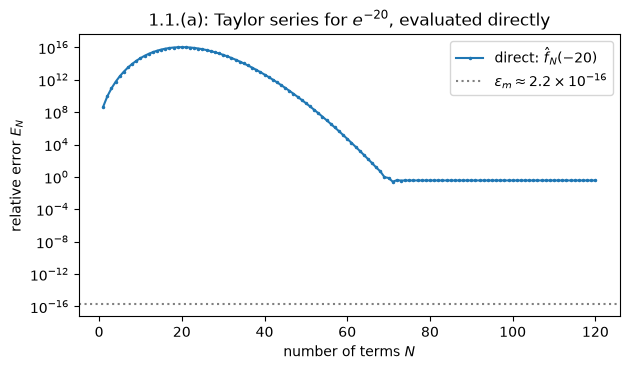

In [28]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.semilogy(Ns, err_direct, ".-", ms=3, label=r"direct: $\hat f_N(-20)$")
ax.axhline(np.finfo(float).eps, color="gray", ls=":", label=r"$\epsilon_m\approx2.2\times10^{-16}$")
ax.set_xlabel("number of terms $N$")
ax.set_ylabel("relative error $E_N$")
ax.set_title(r"1.1.(a): Taylor series for $e^{-20}$, evaluated directly")
ax.legend()
fig.tight_layout()
plt.show()

***1.1.(c) evaluate the series at +20 (all terms positive, no cancellation) and invert***

In [29]:
err_recip = np.array([abs(1.0 / taylor_exp(N, -x0) - exact) / abs(exact) for N in Ns])
R = {}

terms = np.array([x0**n / math.factorial(n) for n in range(120)])
R["taylor"] = {
    "exact": exact,
    "min_err_direct": float(err_direct.min()),
    "N_at_min_direct": int(Ns[err_direct.argmin()]),
    "converged_value_direct": taylor_exp(120, x0),
    "min_err_recip": float(err_recip.min()),
    "N_at_min_recip": int(Ns[err_recip.argmin()]),
    "largest_term": float(np.abs(terms).max()),
    "n_largest_term": int(np.abs(terms).argmax()),
}

***Plotting the Graph for 1.1.(c)***

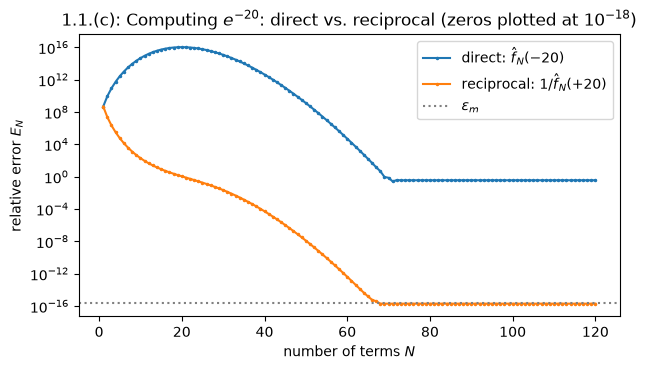

In [30]:


fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.semilogy(Ns, err_direct, ".-", ms=3, label=r"direct: $\hat f_N(-20)$")
ax.semilogy(Ns, np.maximum(err_recip, 1e-18), ".-", ms=3, label=r"reciprocal: $1/\hat f_N(+20)$")
ax.axhline(np.finfo(float).eps, color="gray", ls=":", label=r"$\epsilon_m$")
ax.set_xlabel("number of terms $N$")
ax.set_ylabel("relative error $E_N$")
ax.set_title(r"1.1.(c): Computing $e^{-20}$: direct vs. reciprocal (zeros plotted at $10^{-18}$)")
ax.legend()
fig.tight_layout()
plt.show()

***1.2***

In [31]:
A = np.diag([1e3, 1e-2])
kappa = np.linalg.cond(A)
eps32 = float(np.finfo(np.float32).eps)
N_ops = 1000
R["matvec"] = {
    "kappa": float(kappa),
    "eps_single": eps32,
    "worst_case": float(kappa * N_ops * eps32),
    "random_walk": float(kappa * math.sqrt(N_ops) * eps32),
}


***Problem 3***

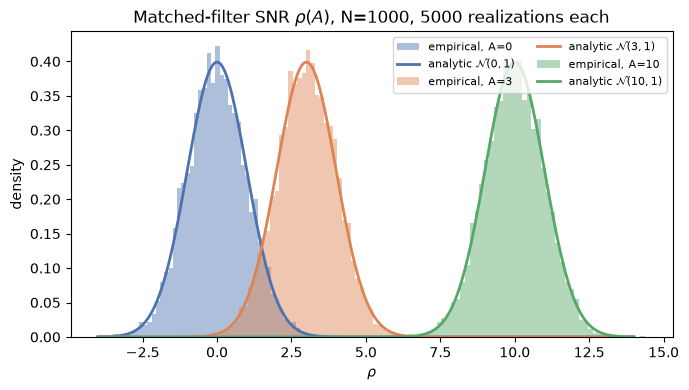

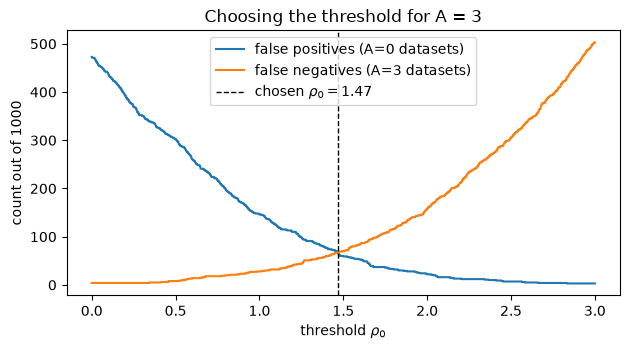

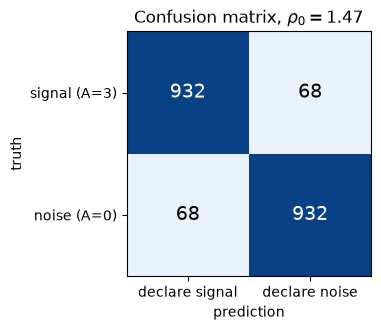

In [33]:
def generate_data(A, N, seed=None):
    rng = np.random.default_rng(seed)
    t = np.linspace(0.0, 2 * np.pi, N)
    dt = (2 * np.pi) / (N - 1)
    s_hat = np.sqrt(dt / np.pi) * np.sin(t)
    s = A * s_hat
    n = rng.normal(loc=0.0, scale=1.0, size=N)
    y = s + n
    return t, y, s, n, s_hat, dt


N = 1000
M = 5000  # realizations per amplitude
amps = [0, 3, 10]
rho = {}
for A_ in amps:
    vals = np.empty(M)
    for k in range(M):
        _, y, _, _, s_hat, _ = generate_data(A_, N, seed=100_000 * (A_ + 1) + k)
        vals[k] = y @ s_hat
    rho[A_] = vals
R["rho_stats"] = {str(a): {"mean": float(rho[a].mean()), "var": float(rho[a].var(ddof=1))} for a in amps}
R["template_norm"] = float(np.sum(generate_data(0, N)[4] ** 2))

fig, ax = plt.subplots(figsize=(7, 4))
colors = {0: "#4C72B0", 3: "#DD8452", 10: "#55A868"}
grid = np.linspace(-4, 14, 600)
for A_ in amps:
    ax.hist(rho[A_], bins=50, density=True, alpha=0.45, color=colors[A_], label=f"empirical, A={A_}")
    ax.plot(grid, norm.pdf(grid, A_, 1), color=colors[A_], lw=2, label=rf"analytic $\mathcal{{N}}({A_},1)$")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel("density")
ax.set_title(rf"Matched-filter SNR $\rho(A)$, N={N}, {M} realizations each")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

# Confusion matrix for A = 3, 1000 datasets of each class
n_each = 1000
rho_noise = np.array([generate_data(0, N, seed=7_000_000 + k)[1] @ generate_data(0, N)[4] for k in range(n_each)])
rho_sig = np.array([generate_data(3, N, seed=8_000_000 + k)[1] @ generate_data(0, N)[4] for k in range(n_each)])
thr = np.linspace(0, 3, 3001)
fp = np.array([(rho_noise >= r).sum() for r in thr])
fn = np.array([(rho_sig < r).sum() for r in thr])
rho0 = float(thr[np.argmin(np.abs(fp - fn))])
TP = int((rho_sig >= rho0).sum()); FN = n_each - TP
FP = int((rho_noise >= rho0).sum()); TN = n_each - FP
R["confusion"] = {"rho0": rho0, "TP": TP, "FN": FN, "FP": FP, "TN": TN,
                  "accuracy": (TP + TN) / (2 * n_each),
                  "theory_rate": float(norm.sf(1.5))}

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(thr, fp, label="false positives (A=0 datasets)")
ax.plot(thr, fn, label="false negatives (A=3 datasets)")
ax.axvline(rho0, color="k", ls="--", lw=1, label=rf"chosen $\rho_0={rho0:.2f}$")
ax.set_xlabel(r"threshold $\rho_0$")
ax.set_ylabel("count out of 1000")
ax.set_title("Choosing the threshold for A = 3")
ax.legend()
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(3.8, 3.4))
cm = np.array([[TP, FN], [FP, TN]])
ax.imshow(cm, cmap="Blues", vmin=0, vmax=n_each)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > 500 else "black")
ax.set_xticks([0, 1], ["declare signal", "declare noise"])
ax.set_yticks([0, 1], ["signal (A=3)", "noise (A=0)"])
ax.set_xlabel("prediction"); ax.set_ylabel("truth")
ax.grid(False)
ax.set_title(rf"Confusion matrix, $\rho_0={rho0:.2f}$")
fig.tight_layout()
plt.show()

***3.1***

load_stream: 8100 samples, dt = 0.063467
validation: [{'K_true': 20, 'det_mean': 18.98420479302832, 'det_sd': 3.4785974622735867, 'energy_mean': 21.17347418616255, 'energy_sd': 5.614805079595254, 'comb_mean': 19.776529495994534, 'comb_sd': 3.523836542113608}, {'K_true': 30, 'det_mean': 27.12690631808279, 'det_sd': 4.198760022243354, 'energy_mean': 30.321533184186553, 'energy_sd': 6.835207570139591, 'comb_mean': 28.51891935022449, 'comb_sd': 4.517306307122008}, {'K_true': 40, 'det_mean': 34.69771241830065, 'det_sd': 4.400908534324734, 'energy_mean': 40.287388546567406, 'energy_sd': 7.3274205749891355, 'comb_mean': 37.57604302120116, 'comb_sd': 5.278212841750884}]
bias factor 0.8901378559086468 calibrated det 29.342961736066428 combined: 30.600332238124007 +/- 4.785191763456604


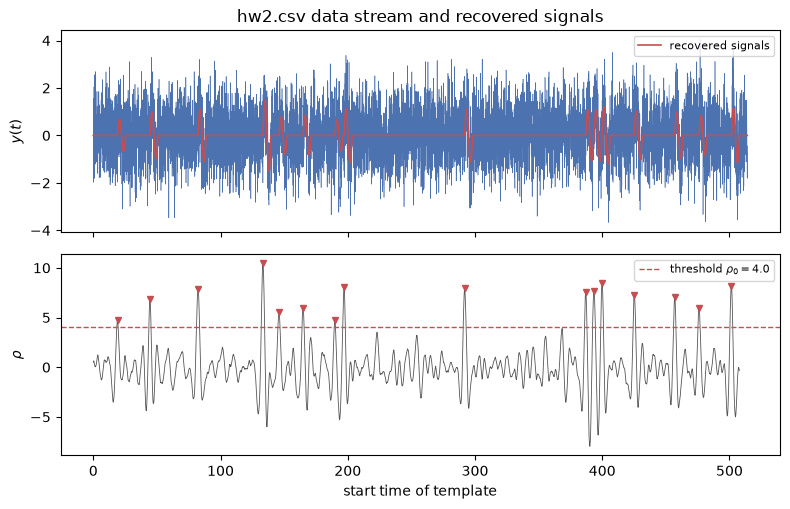

{
  "taylor": {
    "exact": 2.061153622438558e-09,
    "min_err_direct": 0.25998632731602866,
    "N_at_min_direct": 71,
    "converged_value_direct": 1.3081483199294182e-09,
    "min_err_recip": 2.0065962176423985e-16,
    "N_at_min_recip": 68,
    "largest_term": 43099804.12182177,
    "n_largest_term": 19
  },
  "matvec": {
    "kappa": 100000.0,
    "eps_single": 1.1920928955078125e-07,
    "worst_case": 11.920928955078125,
    "random_walk": 0.37697287323097933
  },
  "rho_stats": {
    "0": {
      "mean": -0.0004105720323503164,
      "var": 1.0213221161992507
    },
    "3": {
      "mean": 3.006175286589041,
      "var": 0.9853416757292879
    },
    "10": {
      "mean": 9.986073228920961,
      "var": 0.998057153203135
    }
  },
  "template_norm": 1.0,
  "confusion": {
    "rho0": 1.469,
    "TP": 932,
    "FN": 68,
    "FP": 68,
    "TN": 932,
    "accuracy": 0.932,
    "theory_rate": 0.06680720126885807
  }
}
{'threshold': 3.0, 'n_detected': 20, 'false_alarms': 0.945, 'm

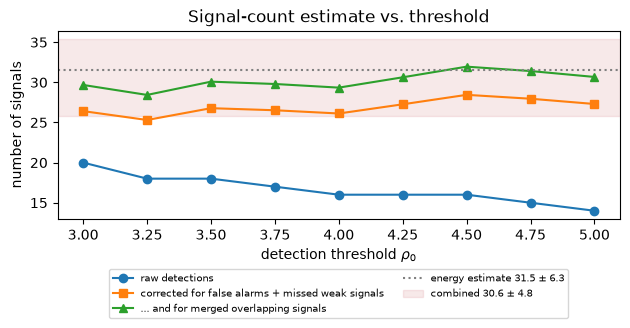

In [34]:
def load_stream(path="hw2.csv"):
    """Read the (t, y) data stream, tolerating header/label lines, a byte-order mark,
    quoted fields, blank lines, ';' separators and a leading index column (e.g. a file re-saved by
    Excel or pandas). Every line that is not purely numeric is skipped; the last two
    numeric fields of each remaining line are taken as (t, y)."""
    rows, skipped = [], []
    with open(path, encoding="utf-8-sig") as fh:
        for line in fh:
            fields = [f.strip().strip('"').strip("'") for f in line.replace(";", ",").split(",")]
            if fields and fields[-1] == "":
                fields = fields[:-1]  # trailing comma
            if not fields or all(f == "" for f in fields):
                continue  # blank line
            try:
                vals = [float(f) for f in fields]  # an empty field (e.g. pandas header ",0,1") fails here
            except ValueError:
                skipped.append(line.strip()[:60])
                continue
            if len(vals) >= 2:
                rows.append(vals[-2:])
    if skipped:
        print(f"load_stream: skipped {len(skipped)} non-numeric line(s), e.g. {skipped[0]!r}")
    data = np.asarray(rows, dtype=float)
    if data.ndim != 2 or len(data) < 100:
        raise ValueError(f"{path}: found only {len(data)} numeric rows -- is this the hw2.csv from the course?")
    steps = np.diff(data[:, 0])
    if not np.allclose(steps, steps[0], rtol=1e-6):
        raise ValueError(f"{path}: first column is not a uniform time grid -- "
                         "the file may have been re-saved or replaced; re-download the original hw2.csv.")
    print(f"load_stream: {len(data)} samples, dt = {steps[0]:.6f}")
    return data[:, 0], data[:, 1]


t_s, y_s = load_stream("hw2.csv")
dt_s = t_s[1] - t_s[0]
L = int(round(2 * np.pi / dt_s)) + 1  # samples spanning one period [0, 2pi]
tmpl = np.sqrt(dt_s / np.pi) * np.sin(np.arange(L) * dt_s)
tmpl /= np.linalg.norm(tmpl)  # unit norm so rho ~ N(A,1) at the true location


def sliding_rho(y):
    """rho[k] = <y[k:k+L], s_hat> for every start index k."""
    return np.correlate(y, tmpl, mode="valid")


def clean_search(y, threshold, max_iter=500):
    """Greedy detection: take the largest rho peak, subtract A*template there, repeat.
    Subtraction removes each signal's sidelobes so they are not counted again,
    and lets overlapping signals be separated."""
    r = y.copy()
    found = []
    for _ in range(max_iter):
        rr = sliding_rho(r)
        k = int(np.argmax(rr))
        if rr[k] < threshold:
            break
        found.append((k, float(rr[k])))
        r[k:k + L] -= rr[k] * tmpl
    return found, r


rho_stream = sliding_rho(y_s)

# (i) false-alarm calibration: run the same search on pure-noise streams of equal length
rng = np.random.default_rng(2026)
thresholds = np.arange(3.0, 5.01, 0.25)
n_noise_trials = 200
fa = {th: [] for th in thresholds}
for _ in range(n_noise_trials):
    z = rng.normal(size=y_s.size)
    f, _ = clean_search(z, thresholds.min())
    peaks = np.array([p[1] for p in f]) if f else np.array([])
    for th in thresholds:
        fa[th].append(int((peaks >= th).sum()))
fa_mean = {float(th): float(np.mean(v)) for th, v in fa.items()}

# (ii) detection efficiency for an injected signal of amplitude A, measured by
#      injection-recovery into noise (accounts for the search maximizing over location)
def efficiency_curve(threshold, A_grid, n_trials=300, seed=11):
    rng_ = np.random.default_rng(seed)
    eff = []
    for A_ in A_grid:
        hit = 0
        for _ in range(n_trials):
            z = rng_.normal(size=600)
            k0 = 250
            z[k0:k0 + L] += A_ * tmpl
            rr = sliding_rho(z)
            win = rr[k0 - L // 4:k0 + L // 4 + 1]  # peak must be near the injection
            hit += win.max() >= threshold
        eff.append(hit / n_trials)
    return np.array(eff)


A_grid = np.linspace(0, 10, 41)
results_by_thr = []
for th in thresholds:
    det, _ = clean_search(y_s, th)
    eff = efficiency_curve(th, A_grid)
    mean_eff = float(np.trapezoid(eff, A_grid) / 10.0)  # averaged over A ~ U(0,10)
    n_det = len(det)
    n_corr = (n_det - fa_mean[float(th)]) / mean_eff
    results_by_thr.append({"threshold": float(th), "n_detected": n_det,
                           "false_alarms": fa_mean[float(th)], "mean_efficiency": mean_eff,
                           "n_corrected": float(n_corr)})

# (iii) independent check from total signal energy: sum A_k^2 = sum y^2 - N (since ||s_hat||=1)
excess_energy = float(np.sum(y_s**2) - y_s.size)
energy_sd = float(np.sqrt(2 * y_s.size))  # sd of a chi^2_N noise term
n_energy = excess_energy / (100.0 / 3.0)  # E[A^2] = 100/3 for A ~ U(0,10)

main_thr = 4.0
det_main, resid = clean_search(y_s, main_thr)
det_main.sort()
best = next(r for r in results_by_thr if r["threshold"] == main_thr)
R["competition"] = {
    "n_samples": int(y_s.size), "dt": float(dt_s), "template_len": L,
    "by_threshold": results_by_thr,
    "excess_energy": excess_energy, "energy_sd": energy_sd, "n_energy": float(n_energy),
    "main_threshold": main_thr,
    "detections": [{"t_start": float(t_s[k]), "A_hat": a} for k, a in det_main],
    "residual_var": float(resid.var()),
}
corr = [r["n_corrected"] for r in results_by_thr]

# Combine the two estimators by inverse-variance weighting.
EA2, VarA2 = 100.0 / 3.0, 2000.0 - (100.0 / 3.0) ** 2  # moments of A^2 for A ~ U(0,10)
eff_main = best["mean_efficiency"]


def estimators(y, n_fa=best["false_alarms"]):
    det, _ = clean_search(y, main_thr)
    n_det = (len(det) - n_fa) / eff_main
    sd_det = np.sqrt(max(len(det), 1)) / eff_main
    n_en = (np.sum(y**2) - y.size) / EA2
    sd_en = np.sqrt(2 * y.size + max(n_en, 1) * VarA2) / EA2
    w1, w2 = 1 / sd_det**2, 1 / sd_en**2
    comb = (w1 * n_det + w2 * n_en) / (w1 + w2)
    return n_det, sd_det, n_en, sd_en, comb, (w1 + w2) ** -0.5


nd, sdd, ne, sde, comb, sdc = estimators(y_s)
R["competition"].update({"det_estimate": float(nd), "det_sd": float(sdd), "energy_estimate": float(ne),
                         "energy_sd_total": float(sde), "combined": float(comb), "combined_sd": float(sdc),
                         "estimate": int(round(comb))})

# Validation: synthetic streams with a known number of signals, A ~ U(0,10), random start times
rng = np.random.default_rng(99)
val = []
for K_true in (20, 30, 40):
    out = []
    for _ in range(60):
        y = rng.normal(size=y_s.size)
        for _k in range(K_true):
            k0 = rng.integers(0, y_s.size - L)
            y[k0:k0 + L] += rng.uniform(0, 10) * tmpl
        e = estimators(y)
        out.append((e[0], e[2], e[4]))
    out = np.array(out)
    val.append({"K_true": K_true, "det_mean": float(out[:, 0].mean()), "det_sd": float(out[:, 0].std()),
                "energy_mean": float(out[:, 1].mean()), "energy_sd": float(out[:, 1].std()),
                "comb_mean": float(out[:, 2].mean()), "comb_sd": float(out[:, 2].std())})
R["competition"]["validation"] = val

# The detection count is biased low when signals overlap (two nearby signals can merge into one
# peak). Calibrate that bias with the validation runs (det_mean ~ a * K_true), then recombine.
Ks = np.array([v["K_true"] for v in val]); dm = np.array([v["det_mean"] for v in val])
a_bias = float(np.sum(dm * Ks) / np.sum(Ks**2))
nd_cal, sdd_cal = nd / a_bias, sdd / a_bias
w1, w2 = 1 / sdd_cal**2, 1 / sde**2
comb_cal = (w1 * nd_cal + w2 * ne) / (w1 + w2)
sd_cal = (w1 + w2) ** -0.5
R["competition"].update({"bias_factor": a_bias, "det_estimate_cal": float(nd_cal), "det_sd_cal": float(sdd_cal),
                         "combined": float(comb_cal), "combined_sd": float(sd_cal),
                         "estimate": int(round(comb_cal))})
with open("results.json", "w") as f:
    json.dump(R, f, indent=2)
print("validation:", val)
print("bias factor", a_bias, "calibrated det", nd_cal, "combined:", comb_cal, "+/-", sd_cal)
with open("bonus.txt", "w") as f:
    f.write(f"{int(round(comb_cal))}\n")

fig, axs = plt.subplots(2, 1, figsize=(8, 5.2), sharex=True)
axs[0].plot(t_s, y_s, lw=0.4, color="#4C72B0")
model = y_s - resid
axs[0].plot(t_s, model, color="#C44E52", lw=1.2, label="recovered signals")
axs[0].set_ylabel("$y(t)$"); axs[0].legend(loc="upper right", fontsize=8)
axs[0].set_title("hw2.csv data stream and recovered signals")
tc = t_s[:rho_stream.size]
axs[1].plot(tc, rho_stream, lw=0.6, color="#555")
axs[1].axhline(main_thr, color="#C44E52", ls="--", lw=1, label=rf"threshold $\rho_0={main_thr}$")
for k, a in det_main:
    axs[1].plot(t_s[k], rho_stream[k], "v", color="#C44E52", ms=4)
axs[1].set_xlabel("start time of template"); axs[1].set_ylabel(r"$\rho$")
axs[1].legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

ths = [r["threshold"] for r in results_by_thr]

with open("results.json", "w") as f:
    json.dump(R, f, indent=2)
print(json.dumps({k: v for k, v in R.items() if k != "competition"}, indent=2))
c = R["competition"]
for r in c["by_threshold"]:
    print(r)
print("energy:", c["excess_energy"], c["n_energy"], "estimate:", c["estimate"])
print("detections at", main_thr, len(c["detections"]))

# Redraw the count figure with the final combined estimate
fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(ths, [r["n_detected"] for r in results_by_thr], "o-", label="raw detections")
ax.plot(ths, corr, "s-", label="corrected for false alarms + missed weak signals")
ax.plot(ths, np.array(corr) / a_bias, "^-", label="... and for merged overlapping signals")
ax.axhline(ne, color="gray", ls=":", label=f"energy estimate {ne:.1f} ± {sde:.1f}")
ax.axhspan(comb_cal - sd_cal, comb_cal + sd_cal, color="#C44E52", alpha=0.12,
           label=f"combined {comb_cal:.1f} ± {sd_cal:.1f}")
ax.set_xlabel(r"detection threshold $\rho_0$"); ax.set_ylabel("number of signals")
ax.set_title("Signal-count estimate vs. threshold")
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.24), ncol=2)
fig.tight_layout()
plt.show()